In [3]:
# Importing necessary libraries

import pandas as pd
import duckdb 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import json

In [4]:
# Connecting to the DuckDB database

con = duckdb.connect("../01_docs/01_data/project.duckdb")

In [5]:
# Testing connection

con.execute("""
            SELECT *
            FROM read_parquet('../01_docs/01_data/02_intermediate/fhvhv_selected.parquet')
            LIMIT 10
            """).df()

,pickup_datetime,request_datetime,pickup_location
0,2024-01-01 00:28:08,2024-01-01 00:21:47,161
1,2024-01-01 00:12:53,2024-01-01 00:10:56,137
2,2024-01-01 00:23:05,2024-01-01 00:20:04,79
3,2024-01-01 00:41:04,2024-01-01 00:35:46,234
4,2024-01-01 00:57:21,2024-01-01 00:48:19,148
5,2024-01-01 00:06:15,2024-01-01 00:03:47,255
6,2024-01-01 00:29:47,2024-01-01 00:22:51,95
7,2024-01-01 00:57:50,2024-01-01 00:45:34,213
8,2024-01-01 00:16:00,2024-01-01 00:11:51,209
9,2024-01-01 00:33:15,2024-01-01 00:26:48,113


In [6]:
# Creating views for easier querying

def create_view_int(con, category, suffix="selected"):
    con.execute(f"""
                CREATE OR REPLACE VIEW {category} AS
                SELECT *
                FROM read_parquet('../01_docs/01_data/02_intermediate/{category}_{suffix}.parquet')
                """)

create_view_int(con, "fhvhv")

create_view_int(con, "fhv", "filtered")

create_view_int(con, "green")

create_view_int(con, "yellow")

In [7]:
# Selecting how much a ride should appear in the map

con.execute("""
            SELECT AVG(pickup_datetime - request_datetime) AS avg_wait_time
            FROM fhvhv
            """).df()

,avg_wait_time
0,0 days 00:04:50.304964


In [20]:
# Combining data from different views by timestamp 

con.execute("""
            CREATE OR REPLACE VIEW aggregated_data AS
            SELECT
                pickup_location,
                time_stamp,
                COUNT(*) AS total_rides
            FROM (
                SELECT
                    pickup_location,
                    CAST(TIME_BUCKET(INTERVAL '15 minutes', CAST(pickup_datetime AS TIMESTAMP)) AS TIME) AS time_stamp
                FROM fhvhv

                UNION ALL

                SELECT
                    pickup_location,
                    CAST(TIME_BUCKET(INTERVAL '15 minutes', CAST(pickup_datetime AS TIMESTAMP)) AS TIME) AS time_stamp
                FROM fhv

                UNION ALL

                SELECT
                    pickup_location,
                    CAST(TIME_BUCKET(INTERVAL '15 minutes', CAST(pickup_datetime AS TIMESTAMP)) AS TIME) AS time_stamp
                FROM green

                UNION ALL

                SELECT
                    pickup_location,
                    CAST(TIME_BUCKET(INTERVAL '15 minutes', CAST(pickup_datetime AS TIMESTAMP)) AS TIME) AS time_stamp
                FROM yellow
            ) t
            GROUP BY pickup_location, time_stamp
            ORDER BY time_stamp, pickup_location;
            """)


In [21]:
con.execute("""
            SELECT *
            FROM aggregated_data
            LIMIT 10
            """).df()

,pickup_location,time_stamp,total_rides
0,1,00:00:00,161
1,2,00:00:00,2
2,3,00:00:00,3756
3,4,00:00:00,11744
4,5,00:00:00,374
5,6,00:00:00,803
6,7,00:00:00,24703
7,8,00:00:00,54
8,9,00:00:00,1413
9,10,00:00:00,5315


In [22]:
con.execute("""SELECT COUNT(*) AS total_rows FROM aggregated_data""").df()

,total_rows
0,25130


In [23]:
zones = gpd.read_file("../01_docs/03_guides/taxi_zones_shapefiles/taxi_zones.shp")

<Axes: >

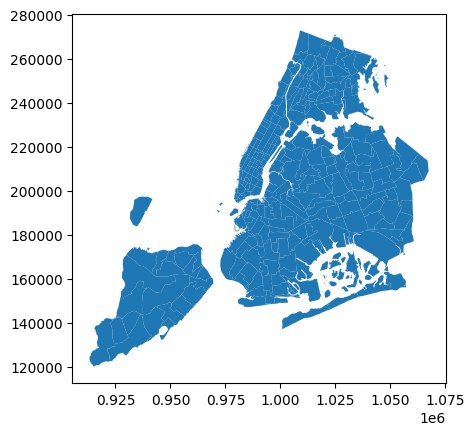

In [24]:
zones.plot()

In [25]:
aggregated_data_df = con.execute("""SELECT * FROM aggregated_data""").df()

In [26]:
print(aggregated_data_df.columns)
print(zones.columns)

Index(['pickup_location', 'time_stamp', 'total_rides'], dtype='str')
Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='str')


In [27]:
merged_df = zones.merge(aggregated_data_df, left_on='LocationID', right_on='pickup_location', how='left')

In [28]:
merged_df.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pickup_location,time_stamp,total_rides
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,00:00:00,161.0
1,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,00:15:00,130.0
2,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,00:30:00,108.0
3,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,00:45:00,88.0
4,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,01:00:00,88.0


In [29]:
print(merged_df.columns)

Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry', 'pickup_location', 'time_stamp', 'total_rides'],
      dtype='str')


In [30]:
merged_df.geometry.head()

0    POLYGON ((933100.918 192536.086, 933091.011 19...
1    POLYGON ((933100.918 192536.086, 933091.011 19...
2    POLYGON ((933100.918 192536.086, 933091.011 19...
3    POLYGON ((933100.918 192536.086, 933091.011 19...
4    POLYGON ((933100.918 192536.086, 933091.011 19...
Name: geometry, dtype: geometry

<Axes: >

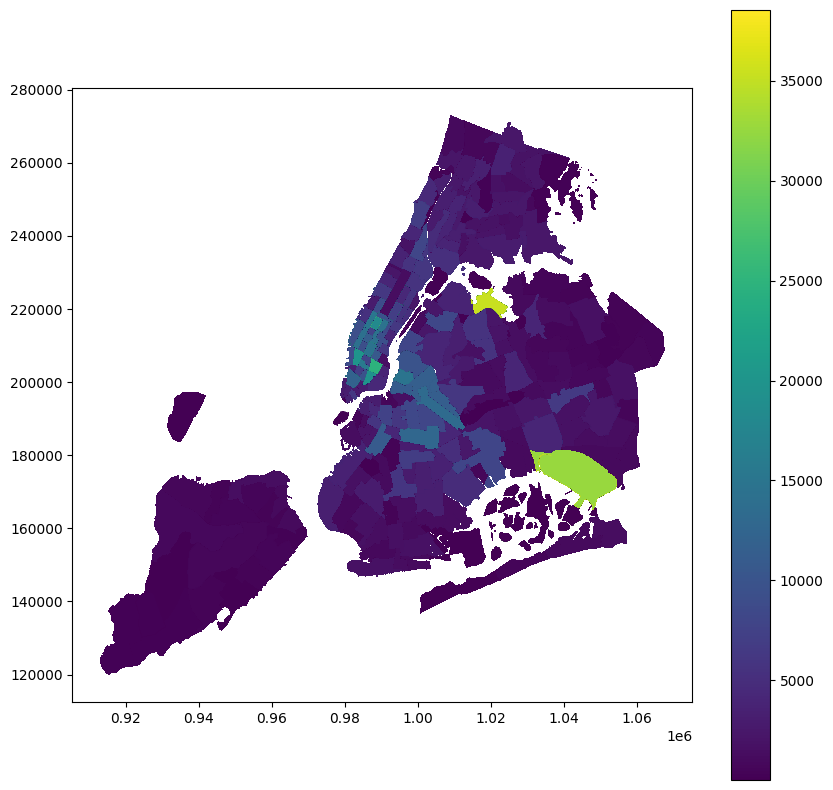

In [ ]:
merged_df.plot(
    column="total_rides",
    legend=True,
    figsize=(10, 10)
)

In [42]:
plot_df = merged_df.copy()
plot_df["time_stamp"] = plot_df["time_stamp"].astype(str)

zones_wgs84 = zones.to_crs(epsg=4326)
geojson = json.loads(zones_wgs84.to_json())

In [32]:
print(geojson.keys())

dict_keys(['type', 'features', 'crs'])


In [33]:
print(len(zones))
print(len(aggregated_data_df))
print(len(merged_df))

263
25130
24940


In [35]:
time = aggregated_data_df["time_stamp"].iloc[0]

df = aggregated_data_df[
    aggregated_data_df["time_stamp"] == time
].copy()

In [36]:
print(len(df))

263


In [43]:
import plotly.express as px

fig = px.choropleth(
    df,
    geojson=geojson,
    locations="pickup_location",
    featureidkey="properties.LocationID",
    color="total_rides",
    hover_name="pickup_location",
    hover_data=["pickup_location", "total_rides"]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [40]:
fig.write_html("nyc_taxi_map.html")

In [41]:
print(zones.crs)

EPSG:2263


In [ ]:
fig = px.choropleth(
    merged_df,
    geojson=geojson,
    locations="LocationID",
    featureidkey="properties.LocationID",
    color="total_rides",
    hover_name="zone",
    hover_data=["borough"],
    animation_frame="time_stamp"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()